Happiness Development Index - 2/22/2026 - davnel2166

In [7]:
import pandas as pd

# Load the dataset
df = pd.read_excel('/home/Flipper/Happiness_Development_Index.xlsx')

# Clean column names (removing any trailing spaces)
df.columns = df.columns.str.strip()

# Transform categorical columns (e.g., Country) into binary columns
# Note: Usually, we exclude 'Country' from regression because it's too unique, 
# but this fulfills the requirement to demonstrate one-hot encoding.
df_encoded = pd.get_dummies(df, columns=['Country'], drop_first=True)

print("Columns after encoding:", df_encoded.columns[:10]) # Displaying first 10 for brevity

Columns after encoding: Index(['HDI Rank', 'Human Development Index (HDI)', 'Life expectancy at birth',
       'Expected years of schooling', 'Mean years of schooling',
       'Gross national income (GNI) per capita', 'Country_Albania',
       'Country_Algeria', 'Country_Andorra', 'Country_Angola'],
      dtype='object')


In [8]:
from sklearn.model_selection import train_test_split

# Define the features and target variable
features = [
    "Life expectancy at birth", 
    "Expected years of schooling", 
    "Mean years of schooling", 
    "Gross national income (GNI) per capita"
]
X = df[features]
y = df["Human Development Index (HDI)"]

# Split the data: 70% for training and 30% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 133
Testing set size: 57


In [9]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model training is complete.")

Model training is complete.


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate performance metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"R-squared Value: {r2:.6f}")

Mean Absolute Error (MAE): 0.016027
Mean Squared Error (MSE): 0.000565
R-squared Value: 0.970315


In [11]:
# Create a DataFrame to view the coefficients (importance)
importance = pd.DataFrame({
    'Feature': features, 
    'Coefficient': model.coef_
})

# Rank the features based on the absolute value of the importance
importance['Absolute_Coefficient'] = importance['Coefficient'].abs()
importance = importance.sort_values(by='Absolute_Coefficient', ascending=False)

print("Feature Importance Ranking:")
print(importance[['Feature', 'Coefficient']])

Feature Importance Ranking:
                                  Feature  Coefficient
2                 Mean years of schooling     0.017782
1             Expected years of schooling     0.012361
0                Life expectancy at birth     0.005868
3  Gross national income (GNI) per capita     0.000001


Actionable features - davnel2166 - 03/01/26

In [12]:
# 1. Identify countries with HDI less than the median
median_hdi = df['Human Development Index (HDI)'].median()
low_hdi_df = df[df['Human Development Index (HDI)'] < median_hdi].copy()

# 2. Simulate Interventions: Increase Life Expectancy by 5% and Mean Schooling by 1.5 years
low_hdi_df['Life expectancy at birth'] = low_hdi_df['Life expectancy at birth'] * 1.05
low_hdi_df['Mean years of schooling'] = low_hdi_df['Mean years of schooling'] + 1.5

# 3. Predict HDI before and after (using your trained 'model')
X_intervention = low_hdi_df[features]
low_hdi_df['Predicted HDI after intervention'] = model.predict(X_intervention)

# Calculate current predictions for baseline comparison
low_hdi_df['Current Predicted HDI'] = model.predict(df[df['Human Development Index (HDI)'] < median_hdi][features])

print(f"Median HDI: {median_hdi:.4f}")
print(f"Average Predicted HDI Increase for Low-HDI Countries: {(low_hdi_df['Predicted HDI after intervention'] - low_hdi_df['Current Predicted HDI']).mean():.4f}")
low_hdi_df[['Life expectancy at birth', 'Mean years of schooling', 'Predicted HDI after intervention']].head()

Median HDI: 0.7395
Average Predicted HDI Increase for Low-HDI Countries: 0.0460


,Life expectancy at birth,Mean years of schooling,Predicted HDI after intervention
95,74.524170,10.923700,0.780148
96,73.731735,11.073026,0.764912
97,77.460495,8.931599,0.767018
98,70.469700,12.421548,0.779174
99,73.788015,11.276801,0.760832


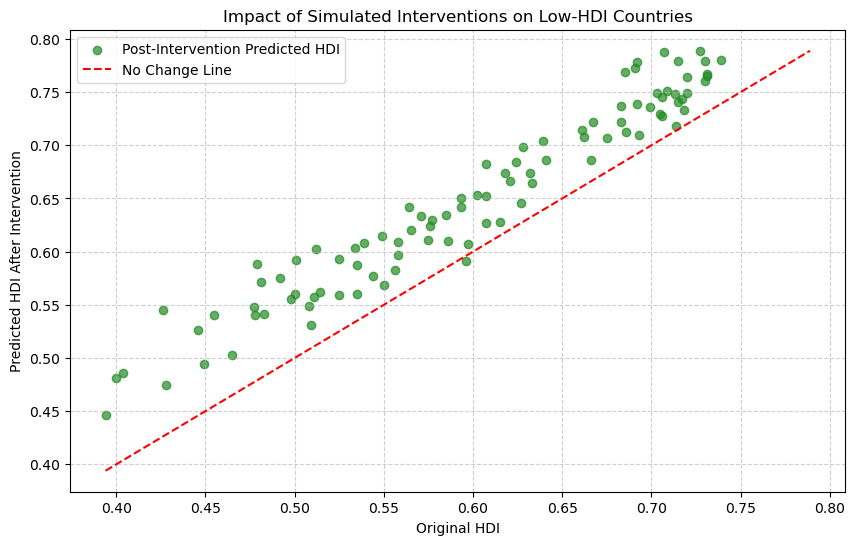

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plotting the change
plt.scatter(low_hdi_df['Human Development Index (HDI)'], 
            low_hdi_df['Predicted HDI after intervention'], 
            alpha=0.7, label='Post-Intervention Predicted HDI', color='forestgreen')

# Reference line (y=x would mean no change)
min_val = min(low_hdi_df['Human Development Index (HDI)'].min(), low_hdi_df['Predicted HDI after intervention'].min())
max_val = max(low_hdi_df['Human Development Index (HDI)'].max(), low_hdi_df['Predicted HDI after intervention'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='No Change Line')

plt.title('Impact of Simulated Interventions on Low-HDI Countries')
plt.xlabel('Original HDI')
plt.ylabel('Predicted HDI After Intervention')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()